In [2]:
# ==========================================================
# Notebook 04: Hybrid Search (TF-IDF + SBERT)
# ==========================================================

import numpy as np
import pandas as pd
import pickle
import faiss

from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
corpus_df = pd.read_csv("data/search_corpus.csv")

documents = corpus_df["text"].tolist()

titles = corpus_df["title"].tolist()

corpus_df.head()

,doc_id,title,category,text,char_length,word_count,source,language,version
0,1,Artificial Intelligence for Beginners,AI,Artificial Intelligence is the simulation of h...,76,10,internal_knowledge_base,en,v1
1,2,Machine Learning Basics,ML,Machine Learning is a subset of Artificial Int...,78,12,internal_knowledge_base,en,v1
2,3,Deep Learning Introduction,DL,Deep Learning uses neural networks with multip...,63,9,internal_knowledge_base,en,v1
3,4,Natural Language Processing,NLP,Natural Language Processing helps computers un...,70,8,internal_knowledge_base,en,v1
4,5,Python Programming,Programming,Python is one of the most popular programming ...,63,11,internal_knowledge_base,en,v1


In [4]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (5, 28)


In [5]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("SBERT model loaded.")

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


SBERT model loaded.


In [10]:
embedding_dim = document_embeddings.shape[1]

faiss_index = faiss.IndexFlatL2(embedding_dim)

faiss_index.add(document_embeddings)

print("Indexed Documents:", faiss_index.ntotal)

Indexed Documents: 5


In [12]:
def tfidf_search(query, vectorizer, tfidf_matrix, documents, top_k=5):

    query_vector = vectorizer.transform([query])

    scores = cosine_similarity(query_vector, tfidf_matrix)[0]

    result_df = pd.DataFrame({"document": documents, "tfidf_score": scores})

    result_df = result_df.sort_values(by="tfidf_score", ascending=False)

    return result_df.head(top_k)

In [13]:
tfidf_search(
    query="Artificial Intelligence",
    vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    documents=titles,
)

,document,tfidf_score
0,Artificial Intelligence for Beginners,0.704272
1,Machine Learning Basics,0.467648
2,Deep Learning Introduction,0.000000
3,Natural Language Processing,0.000000
4,Python Programming,0.000000


In [14]:
def sbert_search(query, model, embeddings, documents, top_k=5):

    query_embedding = model.encode([query]).astype("float32")

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    result_df = pd.DataFrame({"document": documents, "sbert_score": similarities})

    result_df = result_df.sort_values(by="sbert_score", ascending=False)

    return result_df.head(top_k)

In [15]:
sbert_search(
    query="How do I learn AI?",
    model=model,
    embeddings=document_embeddings,
    documents=titles,
)

,document,sbert_score
0,Artificial Intelligence for Beginners,0.550936
4,Python Programming,0.522923
1,Machine Learning Basics,0.462745
3,Natural Language Processing,0.343667
2,Deep Learning Introduction,0.301988


In [16]:
query = "How do I learn AI?"

print("TF-IDF Results:\n")

display(tfidf_search(query, tfidf_vectorizer, tfidf_matrix, titles))

print("\nSBERT Results:\n")

display(sbert_search(query, model, document_embeddings, titles))

TF-IDF Results:



,document,tfidf_score
4,Python Programming,0.447214
0,Artificial Intelligence for Beginners,0.000000
1,Machine Learning Basics,0.000000
2,Deep Learning Introduction,0.000000
3,Natural Language Processing,0.000000



SBERT Results:



,document,sbert_score
0,Artificial Intelligence for Beginners,0.550936
4,Python Programming,0.522923
1,Machine Learning Basics,0.462745
3,Natural Language Processing,0.343667
2,Deep Learning Introduction,0.301988


In [17]:
def min_max_normalize(values):

    values = np.array(values)

    return (values - values.min()) / (values.max() - values.min() + 1e-9)

In [18]:
def hybrid_search(
    query, vectorizer, tfidf_matrix, model, embeddings, documents, alpha=0.7, top_k=5
):

    # TF-IDF scores
    query_vector = vectorizer.transform([query])

    tfidf_scores = cosine_similarity(query_vector, tfidf_matrix)[0]

    # SBERT scores
    query_embedding = model.encode([query])

    sbert_scores = cosine_similarity(query_embedding, embeddings)[0]

    # Normalize
    tfidf_scores = min_max_normalize(tfidf_scores)

    sbert_scores = min_max_normalize(sbert_scores)

    # Fusion
    hybrid_scores = alpha * sbert_scores + (1 - alpha) * tfidf_scores

    results = pd.DataFrame(
        {
            "document": documents,
            "tfidf_score": tfidf_scores,
            "sbert_score": sbert_scores,
            "hybrid_score": hybrid_scores,
        }
    )

    results = results.sort_values(by="hybrid_score", ascending=False)

    return results.head(top_k)

In [19]:
hybrid_search(
    query="How do I learn AI?",
    vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    model=model,
    embeddings=document_embeddings,
    documents=titles,
    alpha=0.7,
)

,document,tfidf_score,sbert_score,hybrid_score
4,Python Programming,1.0,0.887474,0.921232
0,Artificial Intelligence for Beginners,0.0,1.000000,0.700000
1,Machine Learning Basics,0.0,0.645746,0.452023
3,Natural Language Processing,0.0,0.167422,0.117195
2,Deep Learning Introduction,0.0,0.000000,0.000000


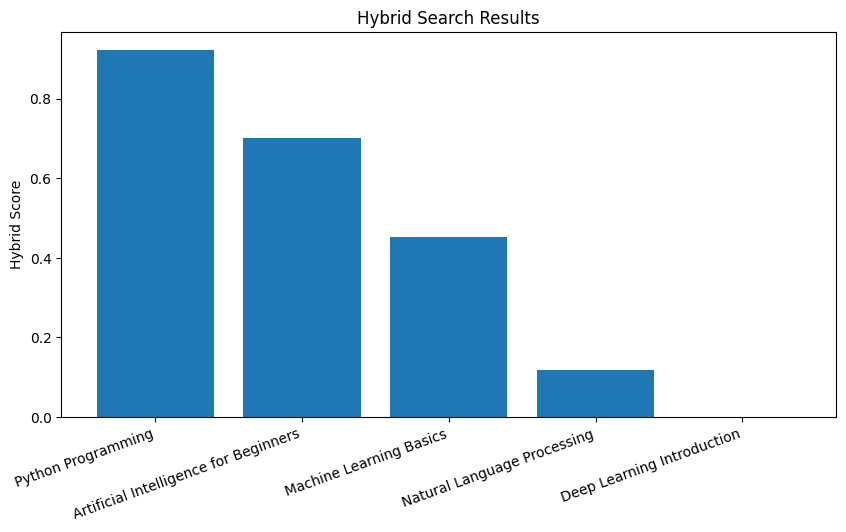

In [20]:
import matplotlib.pyplot as plt

results = hybrid_search(
    query="How do I learn AI?",
    vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    model=model,
    embeddings=document_embeddings,
    documents=titles,
)

plt.figure(figsize=(10, 5))

plt.bar(results["document"], results["hybrid_score"])

plt.xticks(rotation=20, ha="right")

plt.ylabel("Hybrid Score")

plt.title("Hybrid Search Results")

plt.show()

In [21]:
while True:

    user_query = input("\nEnter Query (or quit): ")

    if user_query.lower() == "quit":
        break

    output = hybrid_search(
        query=user_query,
        vectorizer=tfidf_vectorizer,
        tfidf_matrix=tfidf_matrix,
        model=model,
        embeddings=document_embeddings,
        documents=titles,
        alpha=0.7,
        top_k=5,
    )

    print("\nTop Results:\n")
    print(output)


Top Results:

                                document  tfidf_score  sbert_score  \
4                     Python Programming          1.0     0.702153   
0  Artificial Intelligence for Beginners          0.0     1.000000   
1                Machine Learning Basics          0.0     0.532818   
3            Natural Language Processing          0.0     0.152768   
2             Deep Learning Introduction          0.0     0.000000   

   hybrid_score  
4      0.791507  
0      0.700000  
1      0.372973  
3      0.106938  
2      0.000000  

Top Results:

                                document  tfidf_score  sbert_score  \
4                     Python Programming          1.0     0.702153   
0  Artificial Intelligence for Beginners          0.0     1.000000   
1                Machine Learning Basics          0.0     0.532818   
3            Natural Language Processing          0.0     0.152768   
2             Deep Learning Introduction          0.0     0.000000   

   hybrid_score  
4 